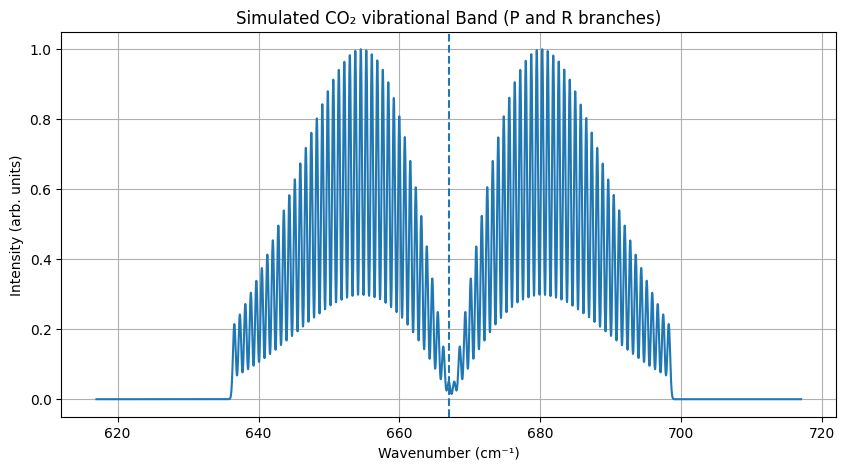

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- Constants ---
B = 0.3902          # rotational constant (cm^-1) for CO2
nu0 = 667.0         # central vibrational frequency (cm^-1), ~15 µm band
T = 300             # temperature (K)
k_B = 0.695         # Boltzmann constant in cm^-1/K

# --- Rotational levels ---
J_max = 40
J = np.arange(0, J_max)

# --- Boltzmann population ---
population = (2*J + 1) * np.exp(-B * J * (J + 1) / (k_B * T))

# --- Transition frequencies ---
# R branch: ΔJ = +1
nu_R = nu0 + 2 * B * (J + 1)

# P branch: ΔJ = -1
nu_P = nu0 - 2 * B * J

# --- Line intensities (proportional to population) ---
I_R = population
I_P = population

# --- Build spectrum grid ---
nu_grid = np.linspace(nu0 - 50, nu0 + 50, 4000)
spectrum = np.zeros_like(nu_grid)

# --- Line shape (Gaussian) ---
def gaussian(x, x0, width=0.2):
    return np.exp(-(x - x0)**2 / (2 * width**2))

# --- Add lines ---
for j in range(len(J)):
    spectrum += I_R[j] * gaussian(nu_grid, nu_R[j])
    spectrum += I_P[j] * gaussian(nu_grid, nu_P[j])

# --- Normalize ---
spectrum /= spectrum.max()

# --- Plot ---
plt.figure(figsize=(10, 5))
plt.plot(nu_grid, spectrum)
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Intensity (arb. units)")
plt.title("Simulated CO₂ vibrational Band (P and R branches)")
plt.grid()

# Mark band center
plt.axvline(nu0, linestyle='--')

plt.show()

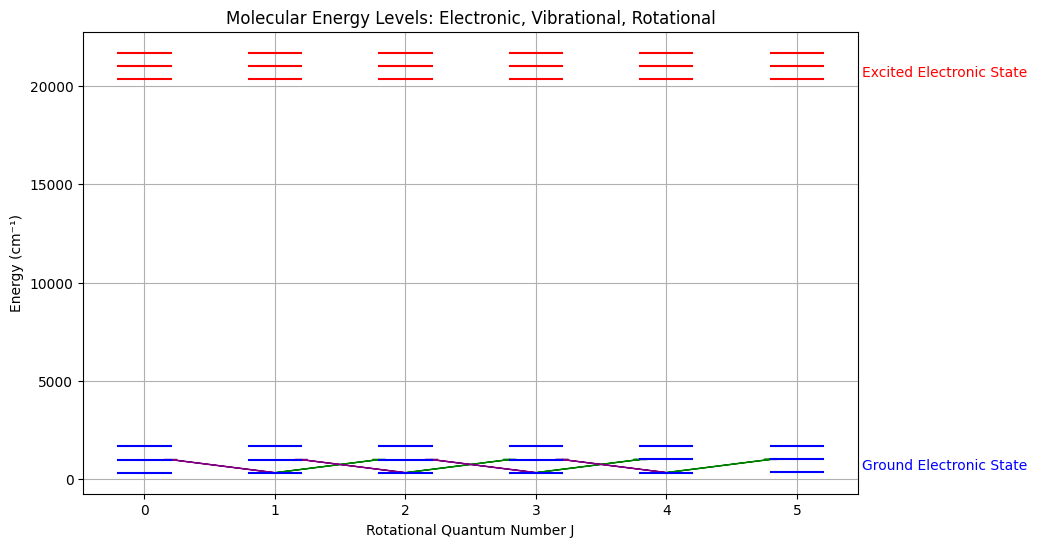

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Constants ---
B = 0.3902        # rotational constant (cm^-1)
hnu = 667.0       # vibrational spacing (cm^-1)
E_elec_excited = 20000  # electronic excited state (cm^-1)

# --- Quantum numbers ---
v_levels = [0, 1, 2]
J_levels = np.arange(0, 6)

# --- Energy functions ---
def E_vib(v):
    return hnu * (v + 0.5)

def E_rot(J):
    return B * J * (J + 1)

# --- Plot setup ---
plt.figure(figsize=(10, 6))

# --- Plot ground electronic state ---
for v in v_levels:
    for J in J_levels:
        E = E_vib(v) + E_rot(J)
        plt.plot([J - 0.2, J + 0.2], [E, E], color='blue')

# --- Plot excited electronic state ---
for v in v_levels:
    for J in J_levels:
        E = E_elec_excited + E_vib(v) + E_rot(J)
        plt.plot([J - 0.2, J + 0.2], [E, E], color='red')

# --- Example transitions (rovibrational: v=0 -> v=1) ---
for J in range(1, 5):
    # R-branch (ΔJ = +1)
    E_lower = E_vib(0) + E_rot(J)
    E_upper = E_vib(1) + E_rot(J + 1)
    plt.arrow(J, E_lower, 0.8, E_upper - E_lower,
              head_width=0.1, length_includes_head=True, color='green')

    # P-branch (ΔJ = -1)
    E_upper = E_vib(1) + E_rot(J - 1)
    plt.arrow(J, E_lower, -0.8, E_upper - E_lower,
              head_width=0.1, length_includes_head=True, color='purple')

# --- Labels ---
plt.xlabel("Rotational Quantum Number J")
plt.ylabel("Energy (cm⁻¹)")
plt.title("Molecular Energy Levels: Electronic, Vibrational, Rotational")

plt.text(5.5, 500, "Ground Electronic State", color='blue')
plt.text(5.5, E_elec_excited + 500, "Excited Electronic State", color='red')

plt.grid()
plt.show()